In [ ]:
# ── 0. Imports & Config ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Directories
PROCESSED_DIR = Path("../Data/Processed")
MODELS_DIR    = Path("../../Models")
FIGURES_DIR   = Path("../../Figures/Supervised_Outputs")
PROCESSED_DIR2 = Path("../../Data/Processed/Supervised_Outputs")
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

MODEL_NAMES = [
    "linear_svm",
    "kernel_svm",
    "cart",
    "random_forest",
    "bagging",
    "knn",
    "naive_bayes",
]

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

In [21]:
# ── 1. Load datasets ──────────────────────────────────────────────────────────
df_simple = pd.read_csv(PROCESSED_DIR / "clothes_size_clean.csv")
df_rich   = pd.read_csv(PROCESSED_DIR / "renttherunway_clean.csv")

print("Simple dataset shape:", df_simple.shape)
print("RTR dataset shape:", df_rich.shape)

Simple dataset shape: (118871, 10)
RTR dataset shape: (192544, 23)


In [22]:
# ── 2. Prepare simple dataset ─────────────────────────────────────────────────
SIMPLE_FEATURES = ["weight_lbs", "age", "height_inches"]
SIMPLE_TARGET   = "fit_equiv_label"   # expected: 0=Small, 1=Fit, 2=Large

df_simple_model = df_simple[SIMPLE_FEATURES + [SIMPLE_TARGET]].dropna().copy()

X_simple = df_simple_model[SIMPLE_FEATURES].copy()
y_simple = df_simple_model[SIMPLE_TARGET].astype(int).copy()

# Optional label encoder for readable class names in reports
label_map = {0: "Small", 1: "Fit", 2: "Large"}
y_simple_str = y_simple.map(label_map)

print(f"Simple dataset usable rows: {len(df_simple_model):,}")
print("Simple class counts:")
print(y_simple.value_counts().sort_index())

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_simple
)

Simple dataset usable rows: 118,871
Simple class counts:
fit_equiv_label
0    31618
1    29496
2    57757
Name: count, dtype: int64


In [ ]:
# ── 3. Load RTR rich-feature saved results ────────────────────────────────────
PROBA_COLS = ["prob_small", "prob_fit", "prob_large"]

def load_model_results(model_name):
    path = PROCESSED_DIR2 / f"{model_name}_fit_probabilities.csv"
    df = pd.read_csv(path)

    y_true = df["true_fit"].astype(int)

    y_pred = df[PROBA_COLS].idxmax(axis=1).map({
        "prob_small": 0,
        "prob_fit": 1,
        "prob_large": 2
    }).astype(int)

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    return {
        "model": model_name,
        "RTR Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "RTR Macro-F1": round(report["macro avg"]["f1-score"], 4),
        "f1_Small": round(report["0"]["f1-score"], 4),
        "f1_Fit": round(report["1"]["f1-score"], 4),
        "f1_Large": round(report["2"]["f1-score"], 4),
    }

rtr_results = pd.DataFrame([load_model_results(m) for m in MODEL_NAMES])
print("RTR (rich feature) results loaded.")
display(rtr_results)

RTR (rich feature) results loaded.


,model,RTR Accuracy,RTR Macro-F1,f1_Small,f1_Fit,f1_Large
0,linear_svm,0.6789,0.3901,0.0139,0.8044,0.3520
1,kernel_svm,0.8467,0.7798,0.6579,0.8964,0.7851
2,cart,0.7269,0.6711,0.5072,0.8048,0.7011
3,random_forest,0.7610,0.7017,0.5592,0.8352,0.7106
4,bagging,0.7720,0.7172,0.5585,0.8434,0.7498
5,knn,0.9074,0.8688,0.7932,0.9353,0.8779
6,naive_bayes,0.4643,0.4068,0.2196,0.5565,0.4442


In [24]:
# ── 4. Define simple-model CV + GridSearch pipelines ──────────────────────────
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

model_configs = {
    "linear_svm": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(random_state=RANDOM_STATE, max_iter=10000))
        ]),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10]
        }
    },
    "kernel_svm": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "clf__C": [0.1, 1, 10],
            "clf__gamma": ["scale", 0.01, 0.1, 1]
        }
    },
    "cart": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "clf__max_depth": [3, 5, 10, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 5]
        }
    },
    "random_forest": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [5, 10, None],
            "clf__min_samples_split": [2, 5],
            "clf__min_samples_leaf": [1, 2]
        }
    },
    "bagging": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", BaggingClassifier(random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_samples": [0.6, 0.8, 1.0],
            "clf__max_features": [0.6, 0.8, 1.0]
        }
    },
    "knn": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "param_grid": {
            "clf__n_neighbors": [3, 5, 7, 9, 11],
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2]
        }
    },
    "naive_bayes": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", GaussianNB())
        ]),
        "param_grid": {
            "clf__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
        }
    }
}

In [ ]:
# ── 5. Run GridSearchCV on simple dataset ─────────────────────────────────────
simple_rows = []
best_simple_models = {}

for model_name, cfg in model_configs.items():
    print(f"\nRunning GridSearchCV for: {model_name}")

    grid = GridSearchCV(
        estimator=cfg["pipeline"],
        param_grid=cfg["param_grid"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    # --- Use subset ONLY for kernel SVM ---
    if model_name == "kernel_svm":
        X_train_subset = X_train_s.sample(20000, random_state=RANDOM_STATE)
        y_train_subset = y_train_s.loc[X_train_subset.index]

        print(f"Kernel SVM using subset: {len(X_train_subset):,} rows")

        grid.fit(X_train_subset, y_train_subset)
    else:
        grid.fit(X_train_s, y_train_s)

    best_model = grid.best_estimator_

    preds = best_model.predict(X_test_s)

    report = classification_report(y_test_s, preds, output_dict=True, zero_division=0)

    # Save best model
    joblib.dump(best_model, MODELS_DIR / f"{model_name}_simple_classifier.joblib")

    pred_df = X_test_s.copy()
    pred_df["true_fit"] = y_test_s.values
    pred_df["pred_fit"] = preds
    pred_df.to_csv(PROCESSED_DIR2 / f"{model_name}_simple_predictions.csv", index=False)

    best_simple_models[model_name] = best_model

    simple_rows.append({
        "model": model_name,
        "Simple Accuracy": round(accuracy_score(y_test_s, preds), 4),
        "Simple Macro-F1": round(report["macro avg"]["f1-score"], 4),
        "Simple CV Best Macro-F1": round(grid.best_score_, 4),
        "Best Params": str(grid.best_params_),
    })

simple_results = pd.DataFrame(simple_rows)

print("\nSimple-feature CV + GridSearch results:")
display(simple_results)


Running GridSearchCV for: linear_svm
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Running GridSearchCV for: kernel_svm
Kernel SVM using subset: 20,000 rows
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Running GridSearchCV for: cart
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Running GridSearchCV for: random_forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Running GridSearchCV for: bagging
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Running GridSearchCV for: knn
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Running GridSearchCV for: naive_bayes
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Simple-feature CV + GridSearch results:


,model,Simple Accuracy,Simple Macro-F1,Simple CV Best Macro-F1,Best Params
0,linear_svm,0.6969,0.5246,0.5233,{'clf__C': 0.1}
1,kernel_svm,0.7286,0.6856,0.6906,"{'clf__C': 1, 'clf__gamma': 1}"
2,cart,0.7359,0.6969,0.6929,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
3,random_forest,0.7384,0.6960,0.6975,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
4,bagging,0.7302,0.6897,0.6912,"{'clf__max_features': 1.0, 'clf__max_samples':..."
5,knn,0.7208,0.6766,0.6807,"{'clf__n_neighbors': 11, 'clf__p': 1, 'clf__we..."
6,naive_bayes,0.6914,0.6617,0.6643,{'clf__var_smoothing': 1e-11}


In [27]:
# ── 6. Side-by-side comparison ────────────────────────────────────────────────
comparison = rtr_results.merge(
    simple_results[["model", "Simple Accuracy", "Simple Macro-F1", "Simple CV Best Macro-F1"]],
    on="model",
    how="inner"
)

comparison["Accuracy Δ"] = (comparison["RTR Accuracy"] - comparison["Simple Accuracy"]).round(4)
comparison["Macro-F1 Δ"] = (comparison["RTR Macro-F1"] - comparison["Simple Macro-F1"]).round(4)

comparison = comparison.set_index("model")
print("\nComparison table:")
display(comparison)


Comparison table:


,RTR Accuracy,RTR Macro-F1,f1_Small,f1_Fit,f1_Large,Simple Accuracy,Simple Macro-F1,Simple CV Best Macro-F1,Accuracy Δ,Macro-F1 Δ
model,,,,,,,,,,
linear_svm,0.6789,0.3901,0.0139,0.8044,0.3520,0.6969,0.5246,0.5233,-0.0180,-0.1345
kernel_svm,0.8467,0.7798,0.6579,0.8964,0.7851,0.7286,0.6856,0.6906,0.1181,0.0942
cart,0.7269,0.6711,0.5072,0.8048,0.7011,0.7359,0.6969,0.6929,-0.0090,-0.0258
random_forest,0.7610,0.7017,0.5592,0.8352,0.7106,0.7384,0.6960,0.6975,0.0226,0.0057
bagging,0.7720,0.7172,0.5585,0.8434,0.7498,0.7302,0.6897,0.6912,0.0418,0.0275
knn,0.9074,0.8688,0.7932,0.9353,0.8779,0.7208,0.6766,0.6807,0.1866,0.1922
naive_bayes,0.4643,0.4068,0.2196,0.5565,0.4442,0.6914,0.6617,0.6643,-0.2271,-0.2549


In [ ]:
# ── 7. Save comparison table ──────────────────────────────────────────────────
comparison.to_csv(PROCESSED_DIR2 / "comparison_rtr_vs_simple.csv")

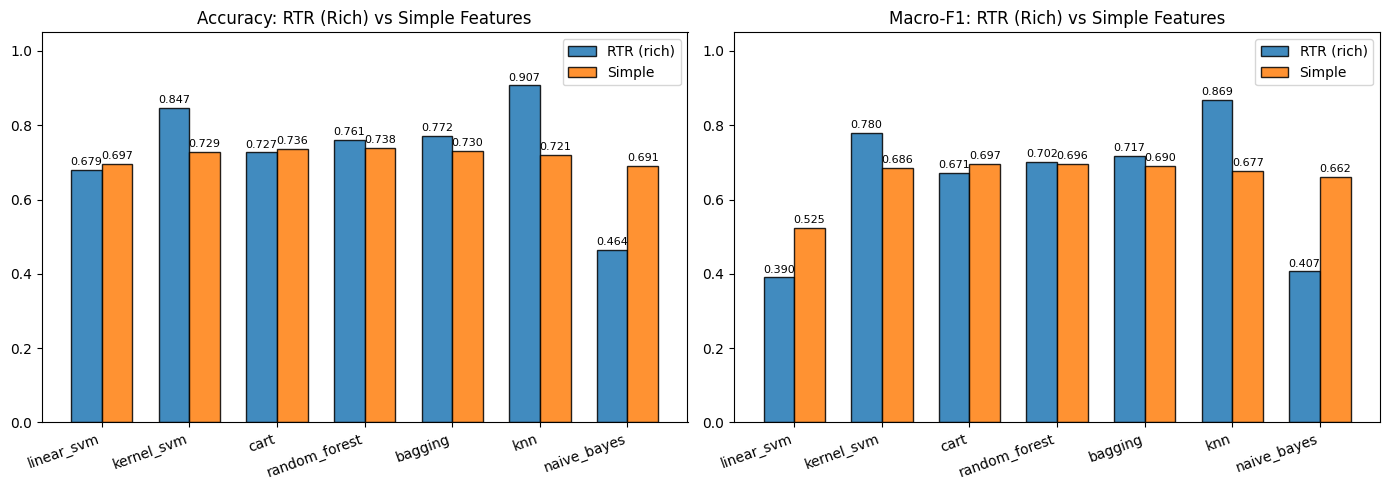

In [29]:
# ── 8. Visualization: RTR vs Simple ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison))
w = 0.35

for ax, metric, title in zip(
    axes,
    [("RTR Accuracy", "Simple Accuracy"), ("RTR Macro-F1", "Simple Macro-F1")],
    ["Accuracy: RTR (Rich) vs Simple Features",
     "Macro-F1: RTR (Rich) vs Simple Features"]
):
    bars1 = ax.bar(x - w/2, comparison[metric[0]], w, label="RTR (rich)", edgecolor="black", alpha=0.85)
    bars2 = ax.bar(x + w/2, comparison[metric[1]], w, label="Simple", edgecolor="black", alpha=0.85)

    ax.bar_label(bars1, fmt="%.3f", padding=2, fontsize=8)
    ax.bar_label(bars2, fmt="%.3f", padding=2, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(comparison.index, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_accuracy_f1_rtr_vs_simple.png", dpi=150, bbox_inches="tight")
plt.show()


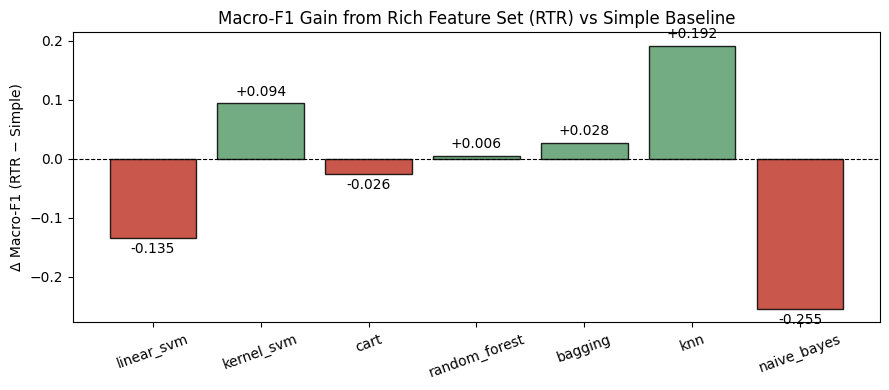

In [30]:
# ── 9. Delta plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

colors = ["#5b9e6d" if v >= 0 else "#c0392b" for v in comparison["Macro-F1 Δ"]]
bars = ax.bar(comparison.index, comparison["Macro-F1 Δ"], color=colors, edgecolor="black", alpha=0.85)
ax.bar_label(bars, fmt="%+.3f", padding=3)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Macro-F1 Gain from Rich Feature Set (RTR) vs Simple Baseline")
ax.set_ylabel("Δ Macro-F1 (RTR − Simple)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_macrof1_delta.png", dpi=150, bbox_inches="tight")
plt.show()

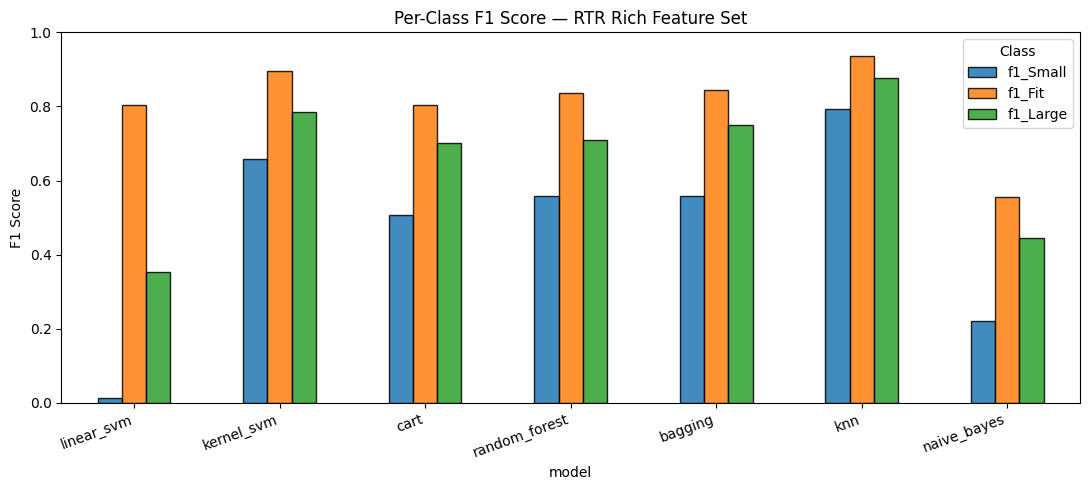

,f1_Small,f1_Fit,f1_Large
model,,,
linear_svm,0.0139,0.8044,0.3520
kernel_svm,0.6579,0.8964,0.7851
cart,0.5072,0.8048,0.7011
random_forest,0.5592,0.8352,0.7106
bagging,0.5585,0.8434,0.7498
knn,0.7932,0.9353,0.8779
naive_bayes,0.2196,0.5565,0.4442


In [31]:
# ── 10. RTR per-class F1 ──────────────────────────────────────────────────────
f1_breakdown = rtr_results.set_index("model")[["f1_Small", "f1_Fit", "f1_Large"]]

f1_breakdown.plot(
    kind="bar",
    figsize=(11, 5),
    edgecolor="black",
    alpha=0.85
)
plt.title("Per-Class F1 Score — RTR Rich Feature Set")
plt.ylabel("F1 Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_perclass_f1_rtr.png", dpi=150, bbox_inches="tight")
plt.show()

display(f1_breakdown)